The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


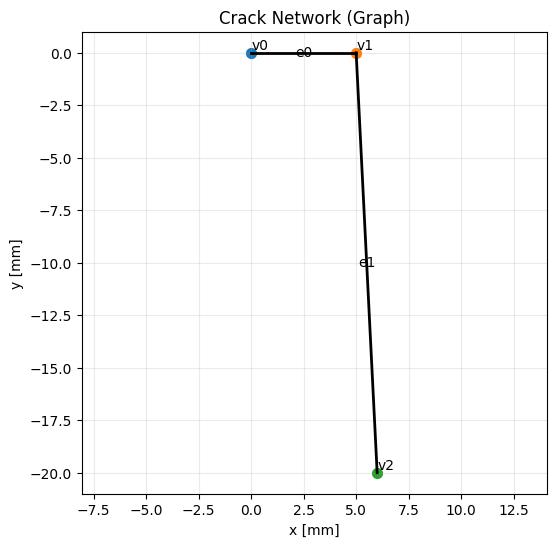

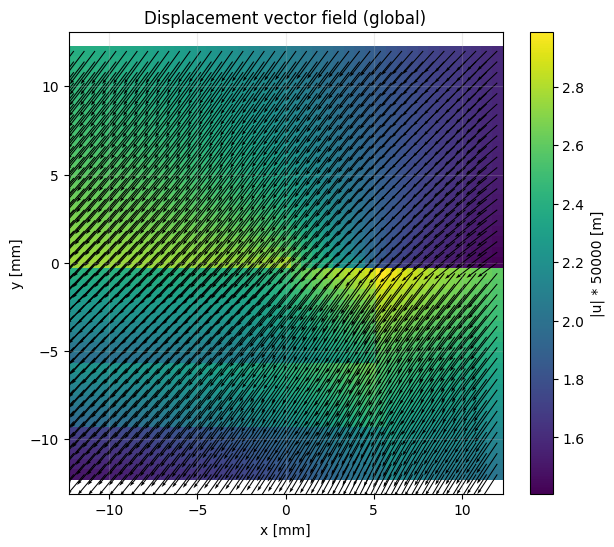

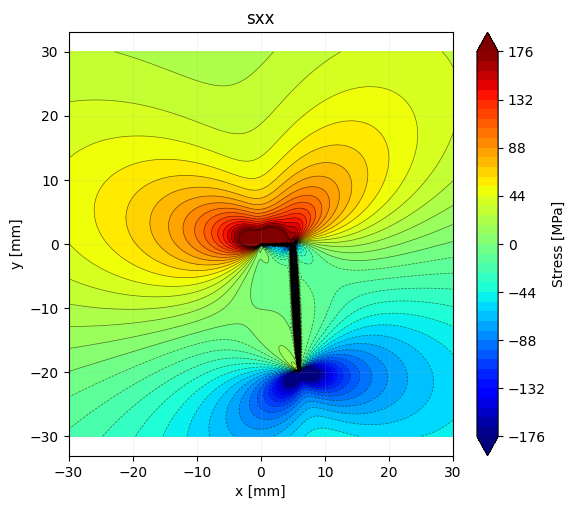

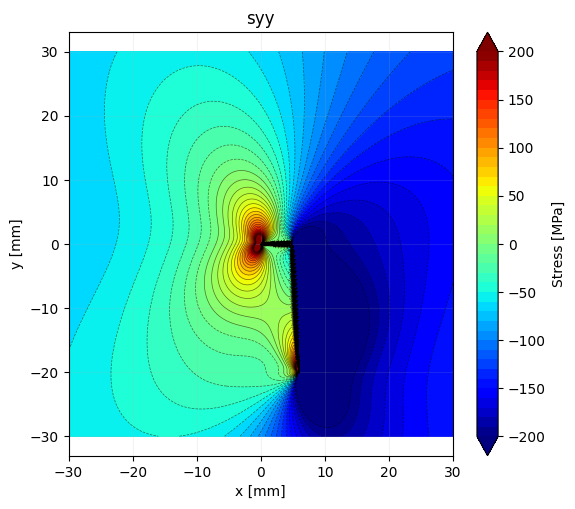

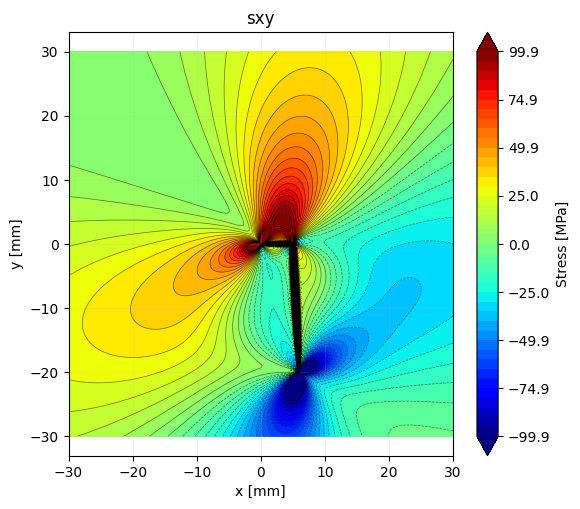

Saved figures to: /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/90DegKink


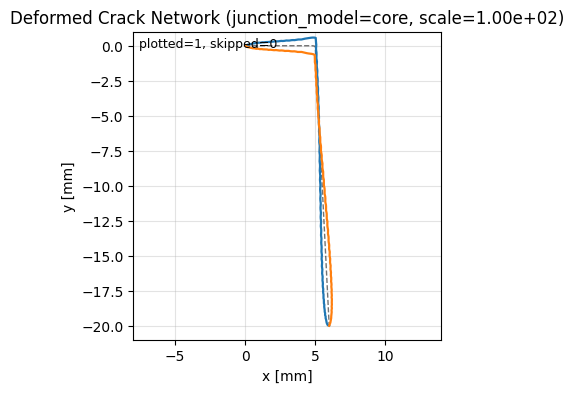

(<Figure size 650x400 with 1 Axes>,
 <Axes: title={'center': 'Deformed Crack Network (junction_model=core, scale=1.00e+02)'}, xlabel='x [mm]', ylabel='y [mm]'>)

In [2]:
from pathlib import Path
import os, sys, importlib
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)
    
from preamble import *
enable_autoreload()
# Output directory
# -------------------------
out_dir = Path(r"/Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/90DegKink")
out_dir.mkdir(parents=True, exist_ok=True)


# -------------------------
# Define Y network: vertices + connectivity
# Units: meters
# -------------------------
mm = 1e-3
vertices = np.array([
    [0,   0.0*mm,  0.0*mm],   # v0 junction
    [1,   5.0*mm,  0*mm], # v1 upper-right
    [2,   6*mm, -20.0*mm], # v2 lower-right
    # [3,   5.0*mm, -4.0*mm], # v3 upper-left
], dtype=float)

# edges: (edge_id, v0, v1)
connectivity = np.array([
    [0, 1],
    [1, 2],
    # [1, 3],
], dtype=int)

net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=0e6, sigma_yy=-100e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)

sol  = calc.solve(
    ne_half=60,
    representation="cheb_quad",
    node_distribution="uniform",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=12,
    nq_stress=16,
    crack_mode="half",
    enforce_cod_nonnegative=True,
    cod_tol=1e-10,
    cod_max_iter=25,
)


res = DCEResultsNetworkV4(calc, sol)
plotter = DCEPlotterV4(res, out_dir=out_dir)

# Graph topology
plotter.plot_network_graph()

# Displacement vector field
plotter.plot_displacement_vector_field(
    extent_factor=1.2,
    n_grid=41,
    scale=1.0,
    disp_scale=5e4,
    mask_cracks=False,
)

# Stress fields (global)
opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=400,
    add_remote=True,
    mask_cracks=False,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2
)
plotter.plot_stress_components_global(opts=opts, components=("sxx","syy","sxy"))

plt.show()
print("Saved figures to:", out_dir)


# ----------------------------
# Plot: deformed network (trim junction faces; smooth COD/CSD if desired)
# ----------------------------
pl_def = DCEPlotterDeformedV4(res, out_dir=out_dir)
pl_def.plot_deformed_network(
    n_pts_per_edge=200,
    scale=1e2,
    show_faces=True,
    units="mm",
    cod_smooth_window=5,
    csd_smooth_window=5,
    junction_model="core",
)


✓ Loaded network: 10 vertices, 8 edges
  Node IDs: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


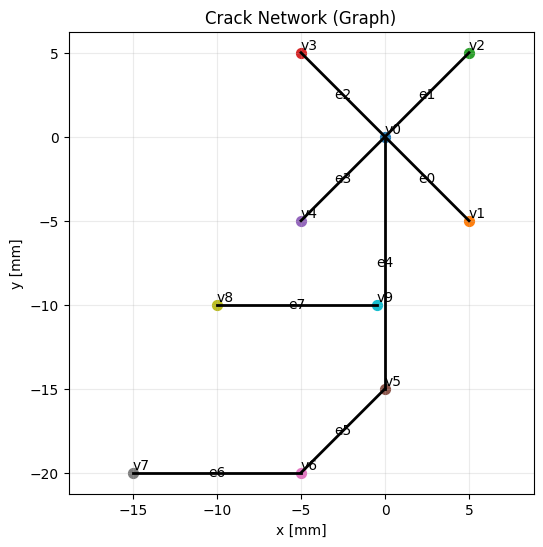

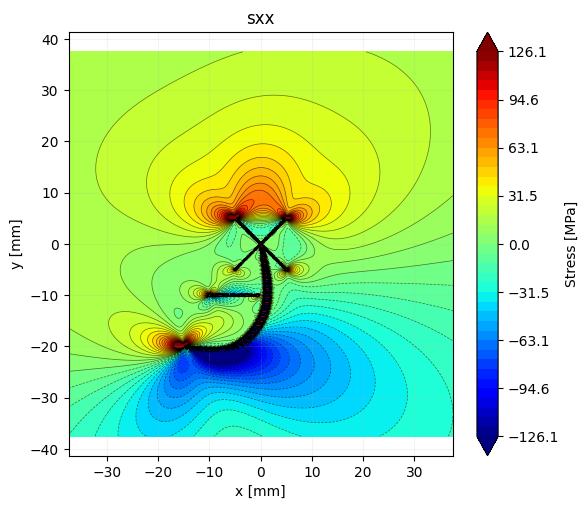

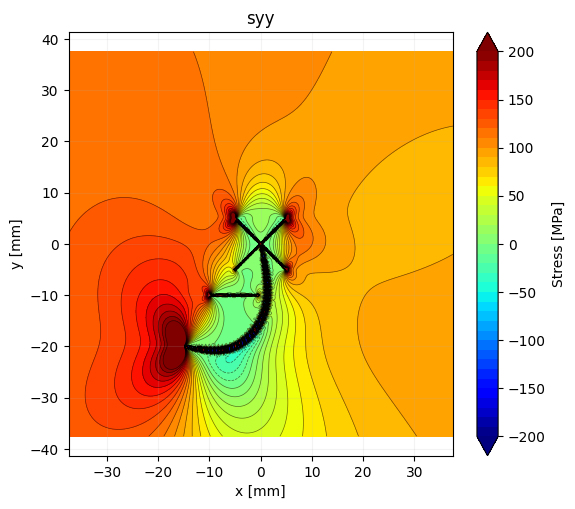

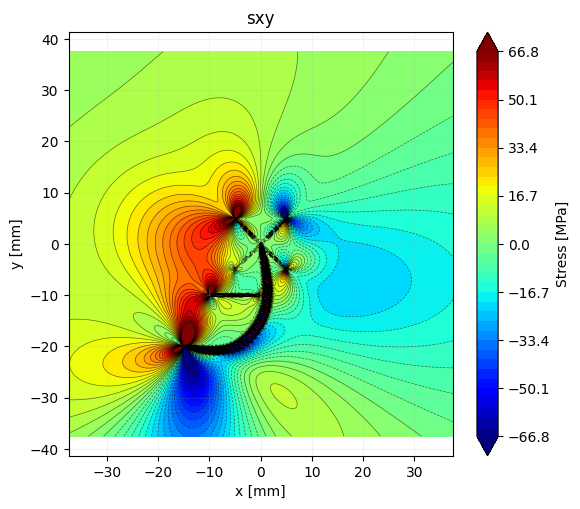

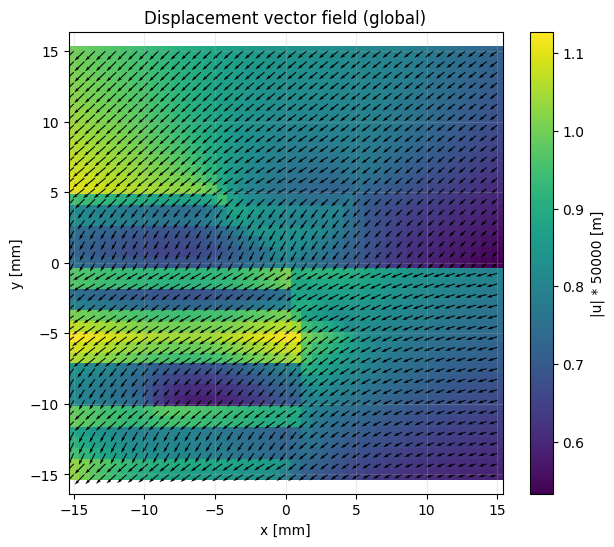

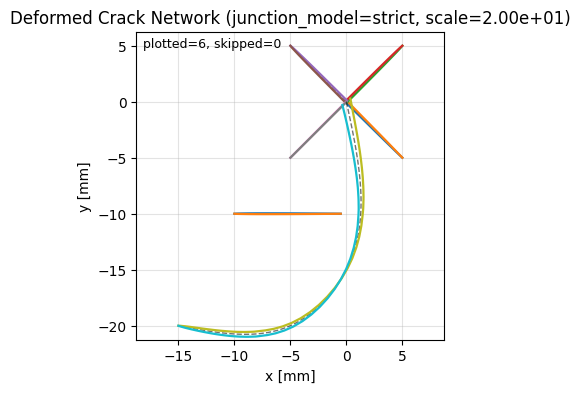

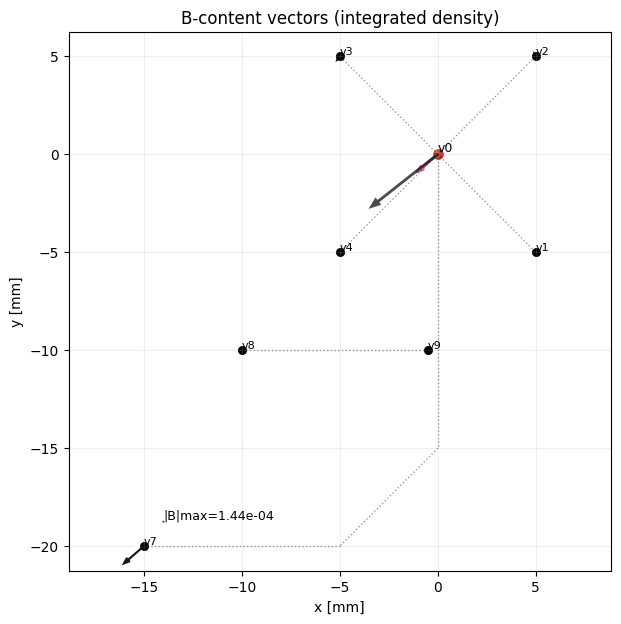

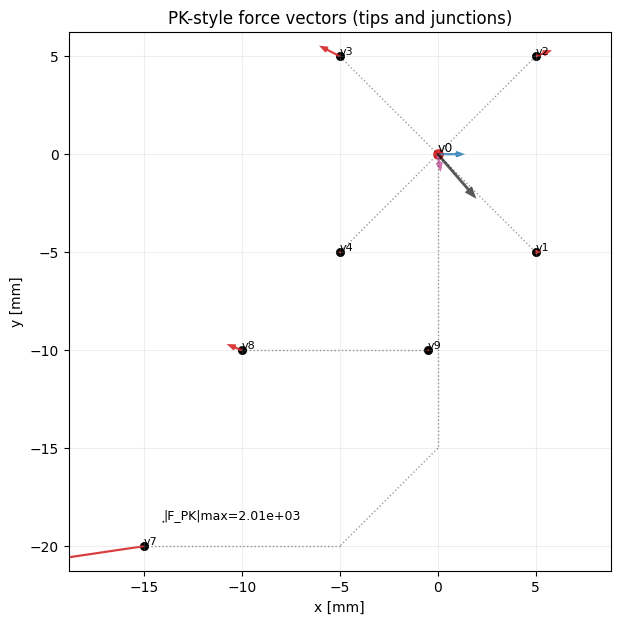

Saved figures to: /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/StarJunctionPolyline


In [1]:
from pathlib import Path
import os, sys

# --- Ensure repo root on sys.path
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

# --- Preamble re-exports
from preamble import *   
enable_autoreload()

# ----------------------------
# Helper: safe plotting calls
# ----------------------------
def _call(obj, name, *args, **kwargs):
    fn = getattr(obj, name, None)
    if fn is None:
        print(f"[skip] {obj.__class__.__name__}.{name} not found")
        return None
    try:
        return fn(*args, **kwargs)
    except TypeError as e:
        # In case signature differs slightly across versions
        print(f"[warn] {obj.__class__.__name__}.{name} signature mismatch: {e}")
        return fn(*args)

mm = 1e-3
vertices = np.array([
    [0,  0.0*mm,  0.0*mm],   # junction
    [1,  5.0*mm, - 5.0*mm],   # left tip
    [2, 5.0*mm,  5.0*mm],   # upper tip
    [3, -5.0*mm, 5.0*mm],
    [4, -5.0*mm, -5.0*mm], 
    [5, 0.0*mm, -15.0*mm], 
    [6, -5.0*mm, -20.0*mm],   # lower tip
    [7, -15.0*mm, -20.0*mm],   # upper tip
    [8, -10.0*mm, -10.0*mm],
    [9, -0.5*mm, -10.0*mm],
    ], dtype=float)

# Each edge: [start_node, end_node]
connectivity = [
    [0, 1],  # Edge 0: from node 0 to node 1
    [0, 2],  # Edge 1: from node 0 to node 2
    [0, 3],  # Edge 2: from node 0 to node 3
    [0, 4],  # Edge 3: from node 0 to node 4
    [0, 5],  # Edge 4: from node 0 to node 5
    [5, 6],  # Edge 5: from node 5 to node 6
    [6, 7],  # Edge 6: from node 6 to node 7
    [8, 9],  # Edge 7: from node 8 to node 9
]

generator = CrackNetworkGenerator(domain_size=(25e-3, 25e-3))
generator.load_from_arrays(vertices, connectivity)

net = CrackNetworkV4.from_vertices_connectivity(vertices=vertices, connectivity=connectivity, Nv_max=8, validate=True)
material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=0e6, sigma_yy=100e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)
sol  = calc.solve(
    ne_half=50,
    representation="cheb_quad",
    node_distribution="uniform",
    solver_option="parametrized_crack",
    parametrization="cubic_spline",
    nq_col=12,
    nq_stress=16,
    crack_mode="half",
    junction_model= "core"
)

res = DCEResultsNetworkV4(calc, sol)

out_dir = Path(r"/Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/StarJunctionPolyline")
out_dir.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Plot: network graph + stress + displacements
# ----------------------------
plotter = DCEPlotterV4(res, out_dir=out_dir)

_call(plotter, "plot_network_graph")

opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=301,
    add_remote=True,
    mask_cracks=False,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2,
)
_call(plotter, "plot_stress_components_global", opts=opts, components=("sxx","syy","sxy"))

# If your core plotter has displacement methods, this will use them automatically.
# Otherwise, it will just skip.
_call(plotter, "plot_displacement_vector_field", disp_scale=5e4, mask_cracks=False)

# ----------------------------
# Plot: deformed network (trim junction faces; smooth COD/CSD if desired)
# ----------------------------
pl_def = DCEPlotterDeformedV4(res, out_dir=out_dir)
_call(
    pl_def,
    "plot_deformed_network",
    scale=2e1,
    trim_core_junction_faces=True,
)

# ----------------------------
# Vectors: B-content and PK forces
# ----------------------------
pkplt = DCEPlotterPK(res, out_dir=out_dir)

_call(
    pkplt,
    "plot_b_content_vectors",
    style=VecPlotStyle(max_len_factor=0.18),
    user_scale=1e-3,
    units="mm",
    show_tips=True,
    show_junctions=True,
    show_sum_at_junction=True,
    annotate=True,
)

_call(
    pkplt,
    "plot_pk_force_vectors",
    style=VecPlotStyle(max_len_factor=0.18),
    user_scale=1e-3,
    units="mm",
    exclude_self=True,
    show_tips=True,
    show_junctions=True,
    n_samples_tip=32,
    annotate=True,
)

plt.show()
print("Saved figures to:", out_dir)

# ----------------------------
# Diagnostics (console)
# ----------------------------
#diagnostics.junction_constraint_diagnostics(calc=calc, sol=sol, min_degree=1)
#diagnostics.jump_vector_diagnostics(calc=calc, sol=sol, min_degree=1, only_vertices=None)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


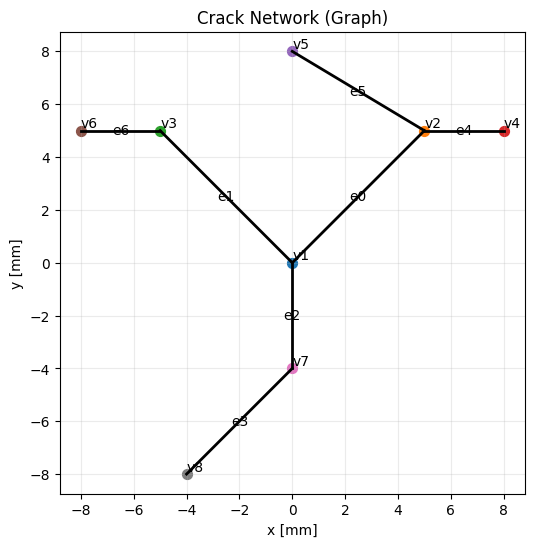

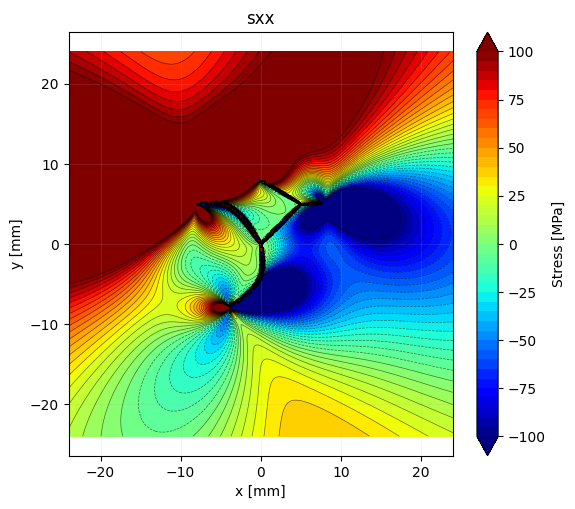

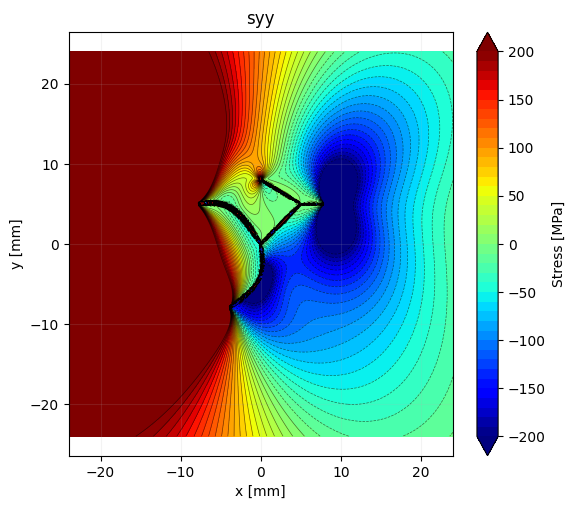

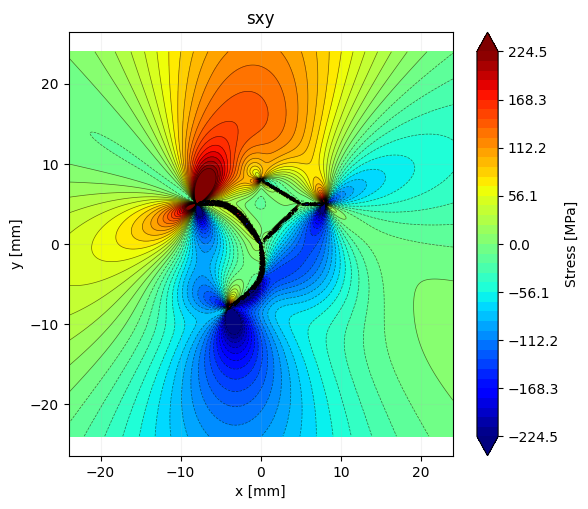

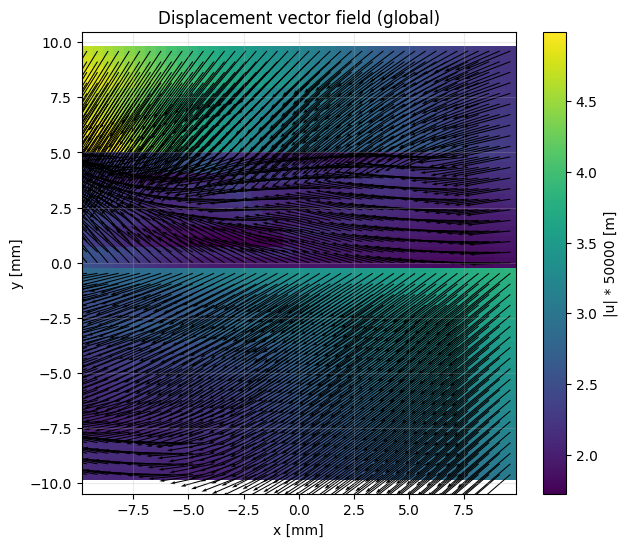

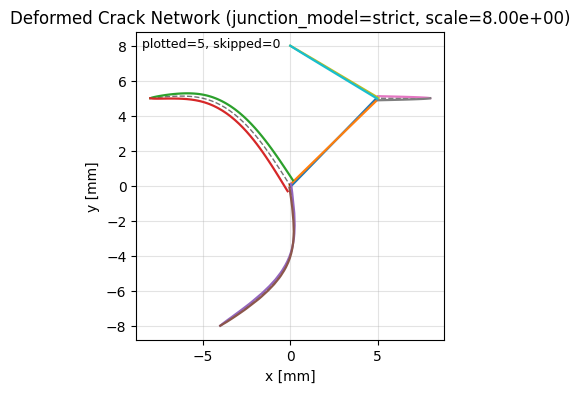

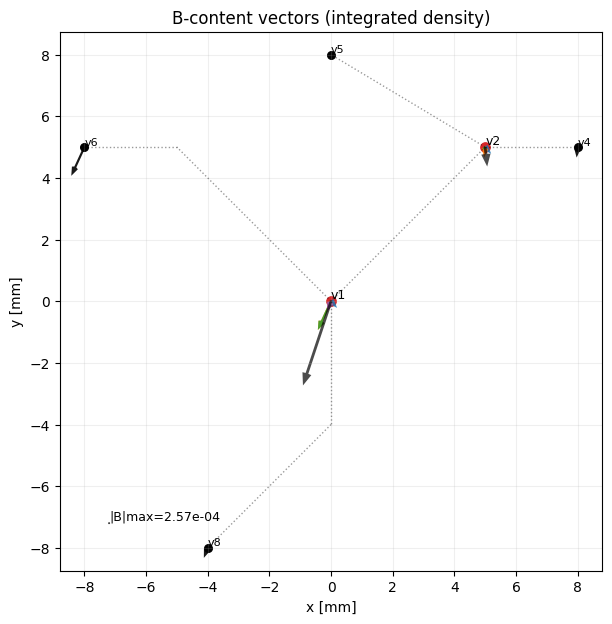

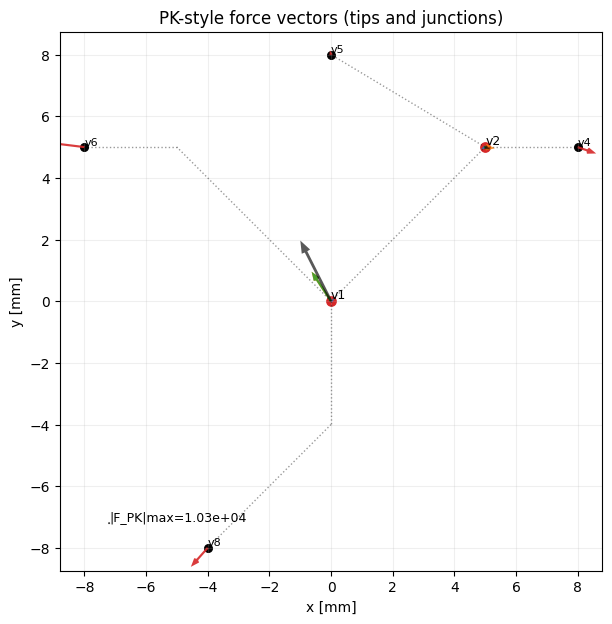

Saved figures to: /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/TreeBranchesSpline


In [3]:
from pathlib import Path
import os, sys

# --- Ensure repo root on sys.path
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

# --- Preamble re-exports
from preamble import *   
enable_autoreload()

# ----------------------------
# Helper: safe plotting calls
# ----------------------------
def _call(obj, name, *args, **kwargs):
    fn = getattr(obj, name, None)
    if fn is None:
        print(f"[skip] {obj.__class__.__name__}.{name} not found")
        return None
    try:
        return fn(*args, **kwargs)
    except TypeError as e:
        # In case signature differs slightly across versions
        print(f"[warn] {obj.__class__.__name__}.{name} signature mismatch: {e}")
        return fn(*args)

# ----------------------------
# Problem definition
# ----------------------------
mm = 1e-3
vertices = np.array([
    [1,  0.0*mm,  0.0*mm],
    [2,  5.0*mm,  5.0*mm],
    [3, -5.0*mm,  5.0*mm],
    [4,  8.0*mm,  5.0*mm],
    [5,  0.0*mm,  8.0*mm],
    [6, -8.0*mm,  5.0*mm],
    [7,  0.0*mm, -4.0*mm],
    [8, -4.0*mm, -8.0*mm],
], dtype=float)

connectivity = np.array([[1,2],[1,3],[1,7],[7,8],[2,4],[2,5],[3,6]], dtype=int)

net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=4,
    validate=True
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=50e6, sigma_yy=100e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)

sol  = calc.solve(
    ne_half=50,
    representation="cheb_quad",
    node_distribution="tip_dense",
    solver_option="parametrized_crack",
    parametrization="cspline",
    nq_col=12,
    nq_stress=16,
    crack_mode="half",
    junction_model="core",
)

res = DCEResultsNetworkV4(calc, sol)

# ----------------------------
# Output directory
# ----------------------------
out_dir = Path(r"/Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/TreeBranchesSpline")
out_dir.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Plot: network graph + stress + displacements
# ----------------------------
plotter = DCEPlotterV4(res, out_dir=out_dir)

_call(plotter, "plot_network_graph")

opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=301,
    add_remote=True,
    mask_cracks=False,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2,
)
_call(plotter, "plot_stress_components_global", opts=opts, components=("sxx","syy","sxy"))

# If your core plotter has displacement methods, this will use them automatically.
# Otherwise, it will just skip.
_call(plotter, "plot_displacement_vector_field", disp_scale=5e4, mask_cracks=False)

# ----------------------------
# Plot: deformed network (trim junction faces; smooth COD/CSD if desired)
# ----------------------------
pl_def = DCEPlotterDeformedV4(res, out_dir=out_dir)
_call(
    pl_def,
    "plot_deformed_network",
    scale=0.8e1,
    trim_core_junction_faces=True,
)

# ----------------------------
# Vectors: B-content and PK forces
# ----------------------------
pkplt = DCEPlotterPK(res, out_dir=out_dir)

_call(
    pkplt,
    "plot_b_content_vectors",
    style=VecPlotStyle(max_len_factor=0.18),
    user_scale=1e-3,
    units="mm",
    show_tips=True,
    show_junctions=True,
    show_sum_at_junction=True,
    annotate=True,
)

_call(
    pkplt,
    "plot_pk_force_vectors",
    style=VecPlotStyle(max_len_factor=0.18),
    user_scale=1e-3,
    units="mm",
    exclude_self=True,
    show_tips=True,
    show_junctions=True,
    n_samples_tip=32,
    annotate=True,
)

plt.show()
print("Saved figures to:", out_dir)

# ----------------------------
# Diagnostics (console)
# ----------------------------
#diagnostics.junction_constraint_diagnostics(calc=calc, sol=sol, min_degree=1)
#diagnostics.jump_vector_diagnostics(calc=calc, sol=sol, min_degree=1, only_vertices=None)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


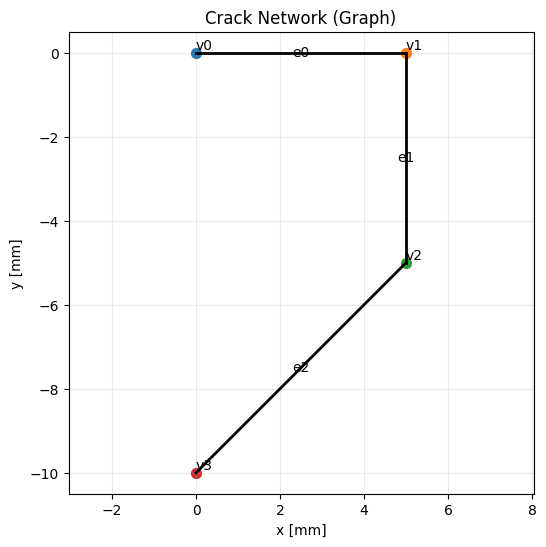

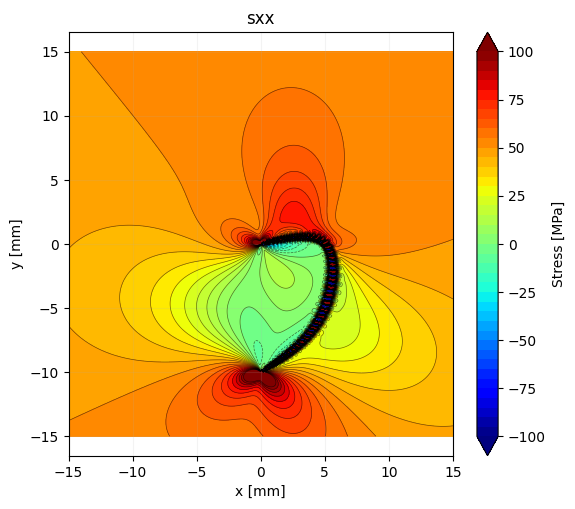

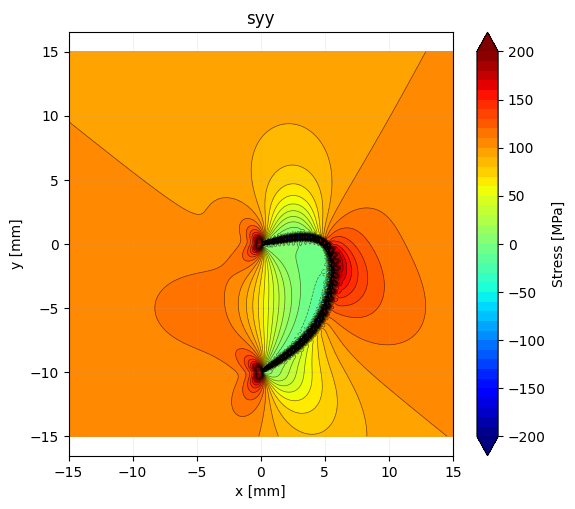

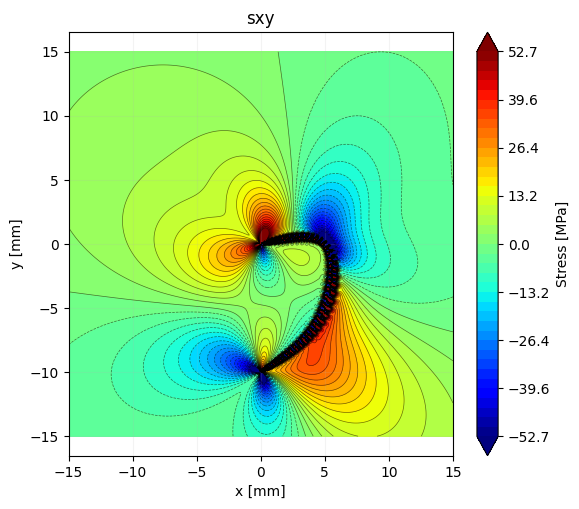

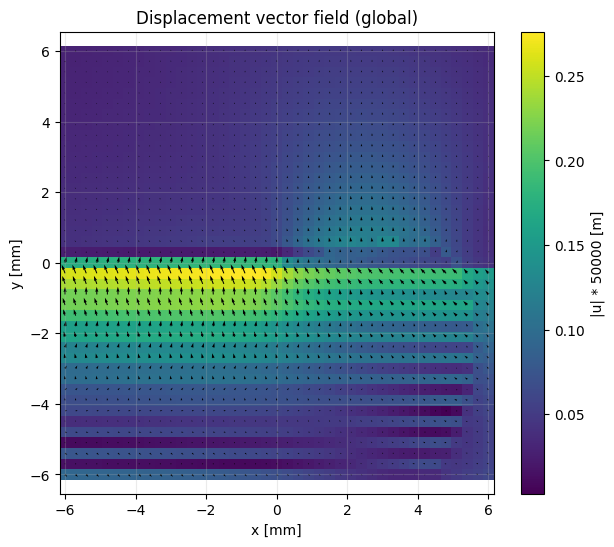

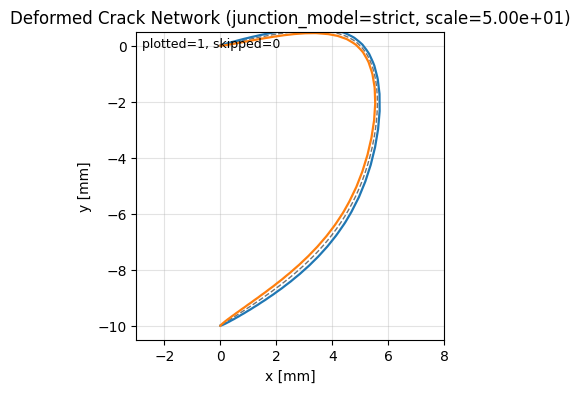

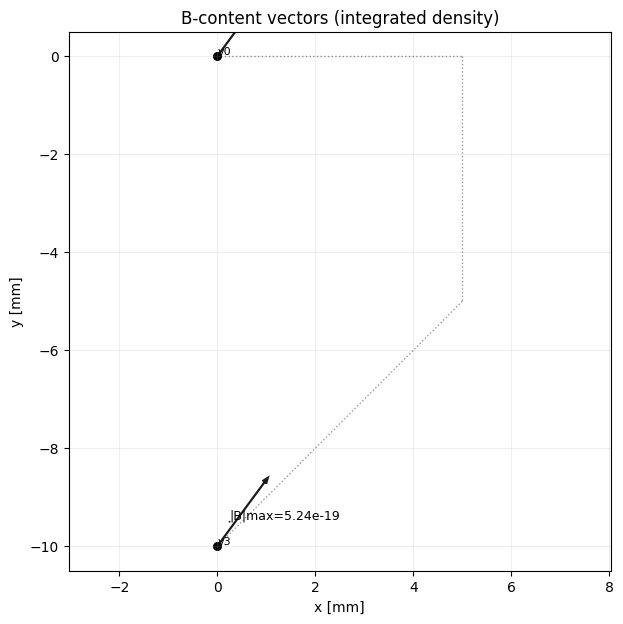

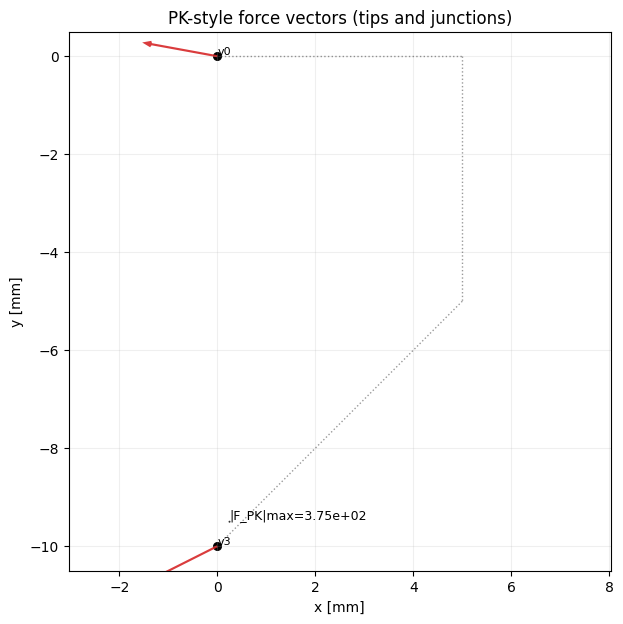

Saved figures to: /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/3SegmentCrackSpline


In [5]:
from pathlib import Path
import os, sys, importlib
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)
    
from preamble import *
enable_autoreload()
# Output directory
# -------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\network-1")
out_dir.mkdir(parents=True, exist_ok=True)


# -------------------------
# Define Y network: vertices + connectivity
# Units: meters
# -------------------------
mm = 1e-3
vertices = np.array([
    [0,   0.0*mm,  0.0*mm],   # v0 junction
    [1,   5.0*mm,  0*mm], # v1 upper-right
    [2,   5.0*mm, -5.0*mm], # v2 lower-right
    [3,  0*mm,  -10.0*mm], # v3 extended lower-right
], dtype=float)

# edges: (edge_id, v0, v1)
connectivity = np.array([
    [0, 1],
    [1, 2],
    [2, 3]
], dtype=int)

net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=4,
    validate=True
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=50e6, sigma_yy=100e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)

sol  = calc.solve(
    ne_half=50,
    representation="cheb_quad",
    node_distribution="tip_dense",
    solver_option="parametrized_crack",
    parametrization="cspline",
    nq_col=12,
    nq_stress=16,
    crack_mode="half",
    junction_model="core",
)

res = DCEResultsNetworkV4(calc, sol)

# ----------------------------
# Output directory
# ----------------------------
out_dir = Path(r"/Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/3SegmentCrackSpline")
out_dir.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Plot: network graph + stress + displacements
# ----------------------------
plotter = DCEPlotterV4(res, out_dir=out_dir)

_call(plotter, "plot_network_graph")

opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=301,
    add_remote=True,
    mask_cracks=False,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2,
)
_call(plotter, "plot_stress_components_global", opts=opts, components=("sxx","syy","sxy"))

# If your core plotter has displacement methods, this will use them automatically.
# Otherwise, it will just skip.
_call(plotter, "plot_displacement_vector_field", disp_scale=5e4, mask_cracks=False)

# ----------------------------
# Plot: deformed network (trim junction faces; smooth COD/CSD if desired)
# ----------------------------
pl_def = DCEPlotterDeformedV4(res, out_dir=out_dir)
_call(
    pl_def,
    "plot_deformed_network",
    scale=5e1,
    trim_core_junction_faces=True,
)

# ----------------------------
# Vectors: B-content and PK forces
# ----------------------------
pkplt = DCEPlotterPK(res, out_dir=out_dir)

_call(
    pkplt,
    "plot_b_content_vectors",
    style=VecPlotStyle(max_len_factor=0.18),
    user_scale=1e-3,
    units="mm",
    show_tips=True,
    show_junctions=True,
    show_sum_at_junction=True,
    annotate=True,
)

_call(
    pkplt,
    "plot_pk_force_vectors",
    style=VecPlotStyle(max_len_factor=0.18),
    user_scale=1e-3,
    units="mm",
    exclude_self=True,
    show_tips=True,
    show_junctions=True,
    n_samples_tip=32,
    annotate=True,
)

plt.show()
print("Saved figures to:", out_dir)


# ----------------------------
# Diagnostics (console)
# ----------------------------
#diagnostics.junction_constraint_diagnostics(calc=calc, sol=sol, min_degree=1)
#diagnostics.jump_vector_diagnostics(calc=calc, sol=sol, min_degree=1, only_vertices=None)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Detecting edge intersections...
Found 3 intersection(s)
  Created junction node 53 at (-2.05, 5.86) mm
    Split edge (1, 2) into 1-53 and 53-2
    Split edge (45, 46) into 45-53 and 53-46
  Created junction node 54 at (-5.87, 0.49) mm
    Split edge (4, 5) into 4-54 and 54-5
    Split edge (40, 41) into 40-54 and 54-41
  Created junction node 55 at (0.28, -5.62) mm
    Split edge (12, 13) into 12-55 and 55-13
    Split edge (23, 24) into 23-55 and 55-24
Successfully processed 3 intersection(s)


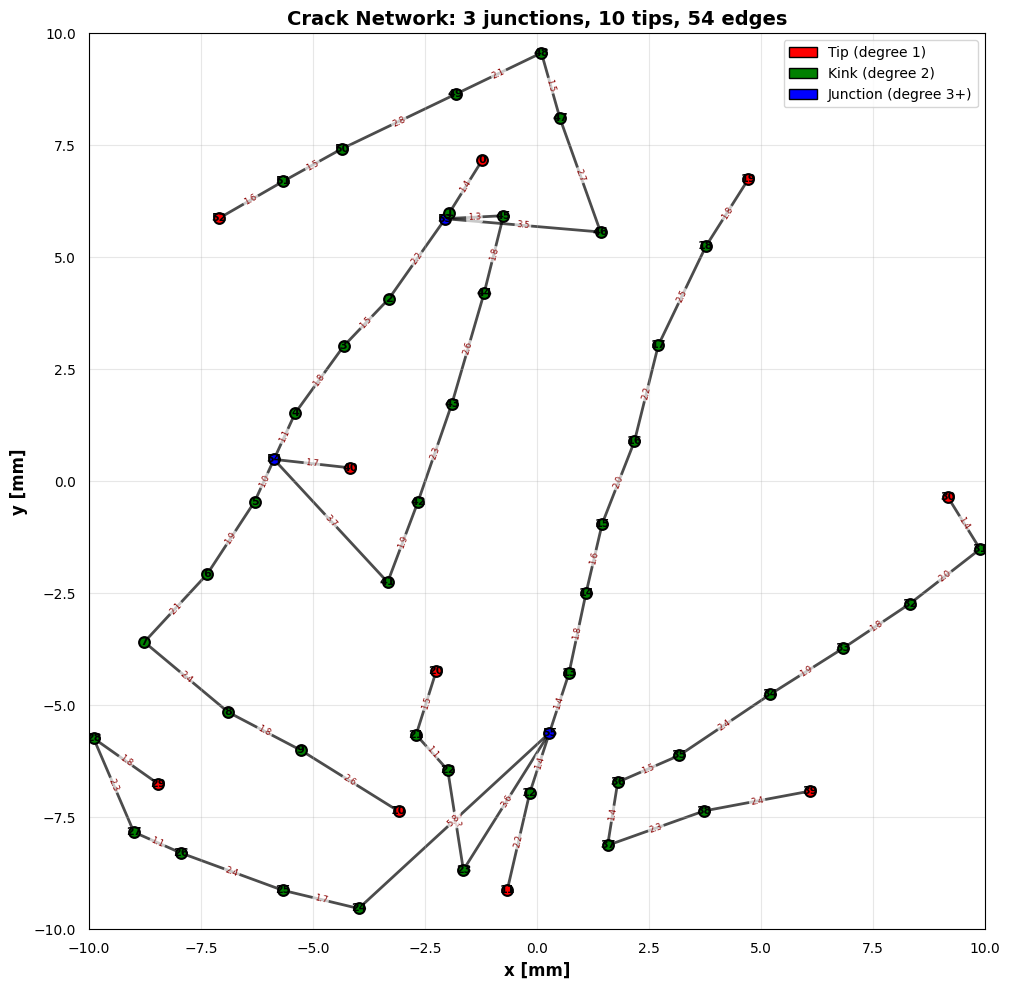

CRACK NETWORK STATISTICS

Vertices:
  Total: 56
  Tips (degree 1): 10
  Kinks (degree 2): 43
  Junctions (degree 3+): 3

Edges:
  Total: 54
  Length range: [0.16, 5.79] mm
  Mean length: 2.01 mm
  Std dev: 0.82 mm

Degree distribution:
  Degree 1: 10 vertices
  Degree 2: 43 vertices
  Degree 4: 3 vertices

Connected components (paths): 3
  Path 1: 26 vertices, 26 edges
  Path 2: 20 vertices, 19 edges
  Path 3: 10 vertices, 9 edges


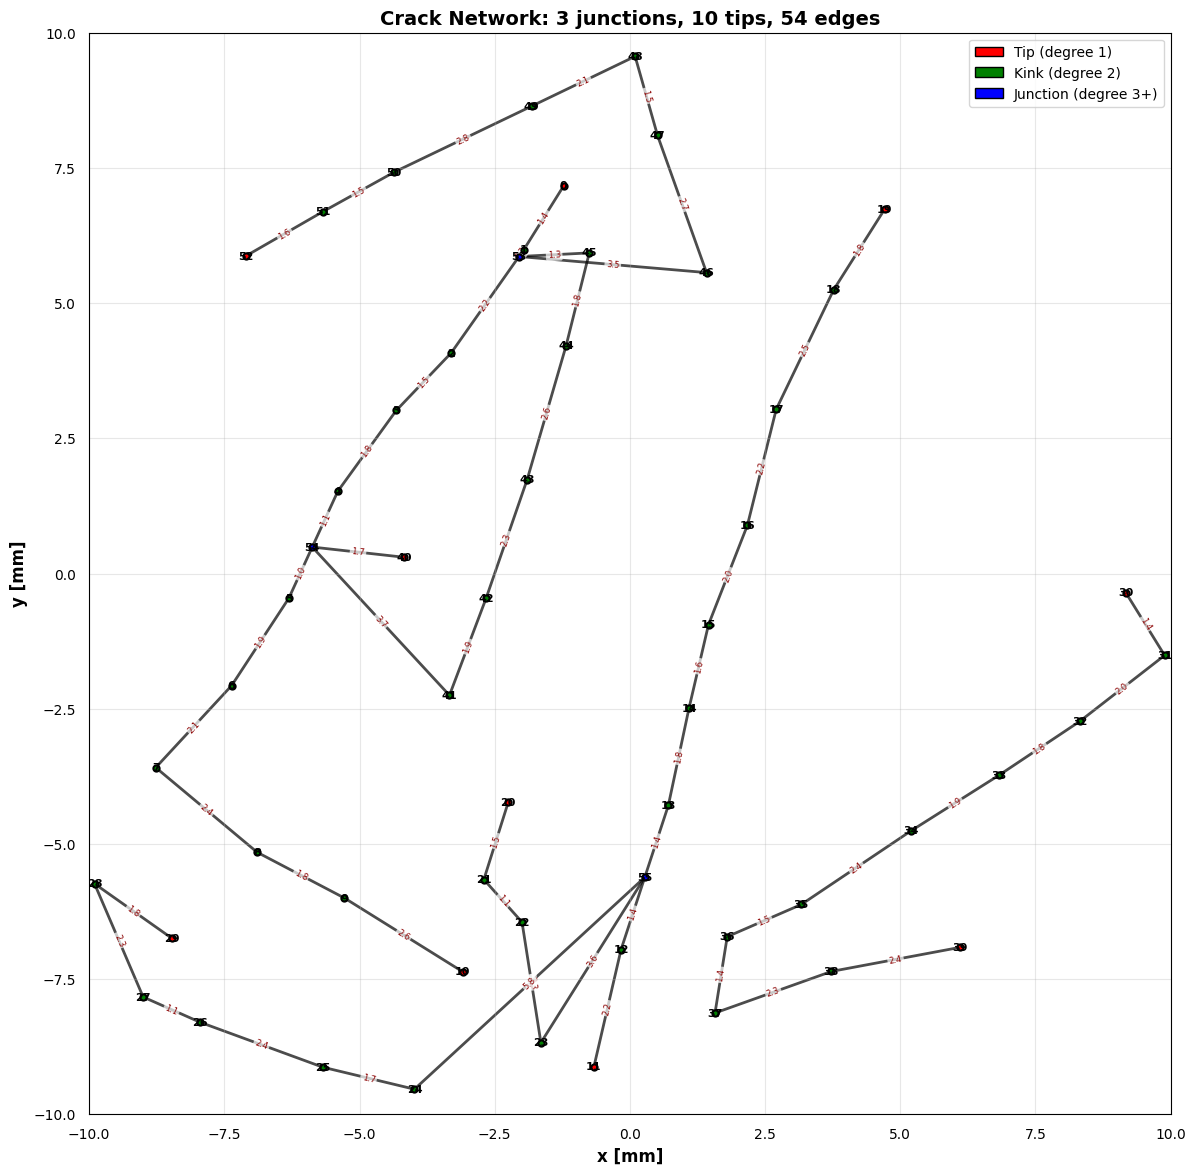

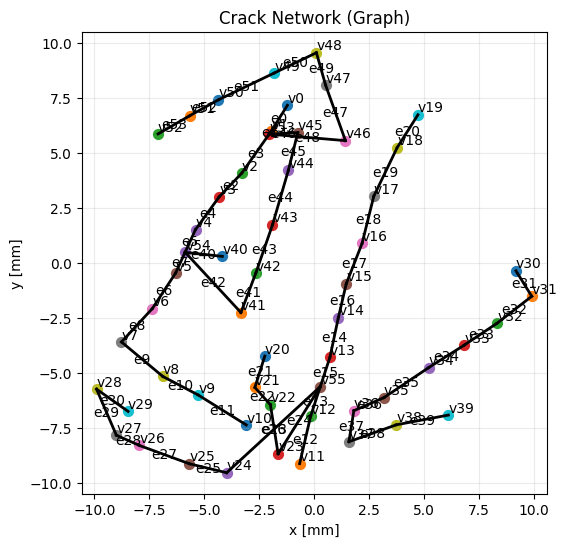

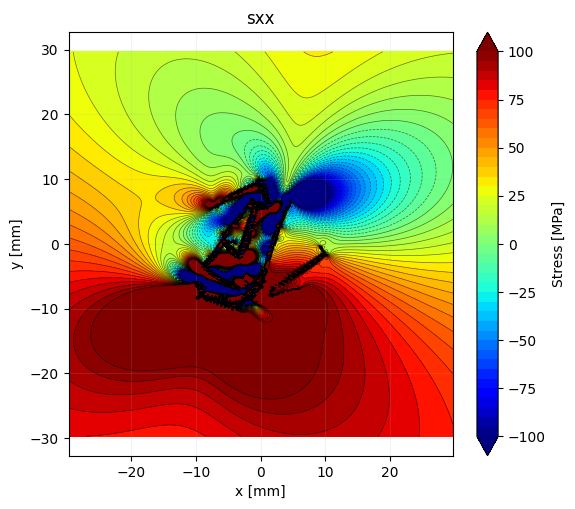

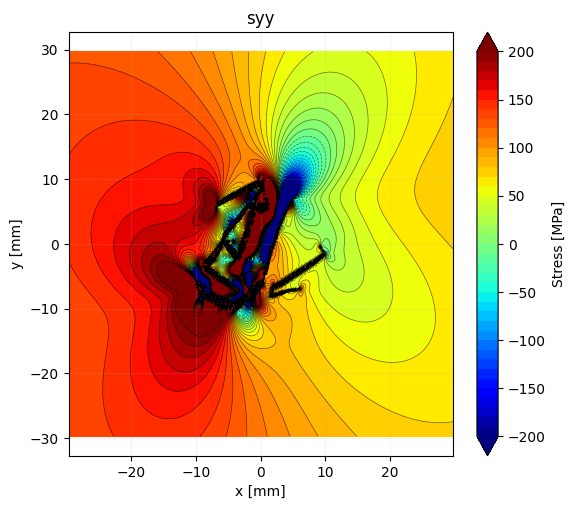

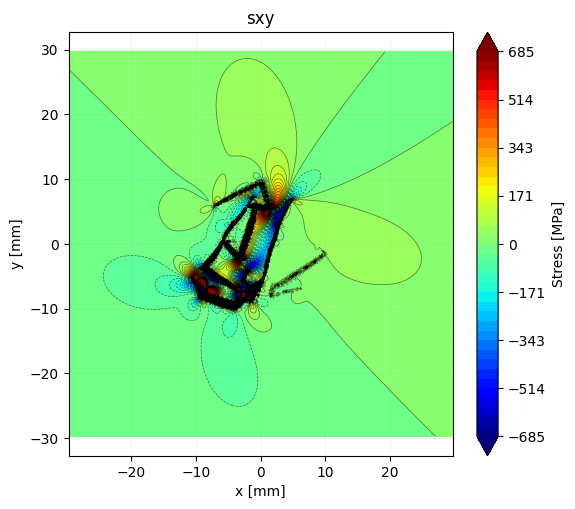

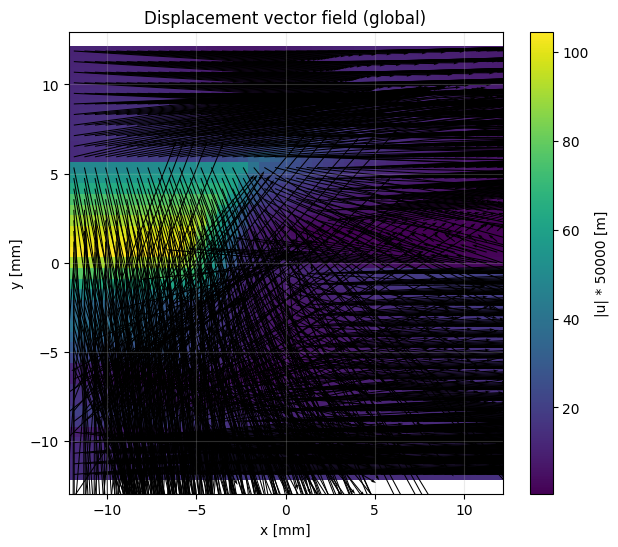

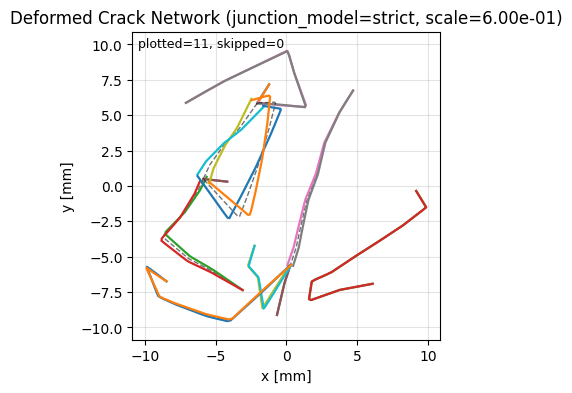

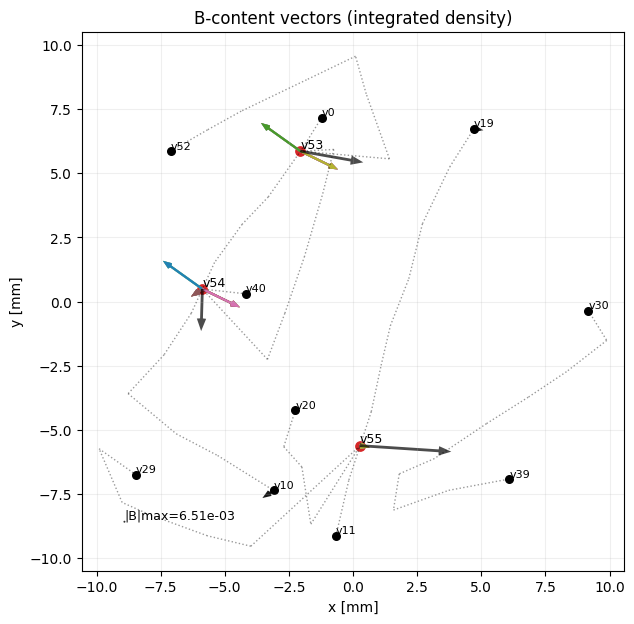

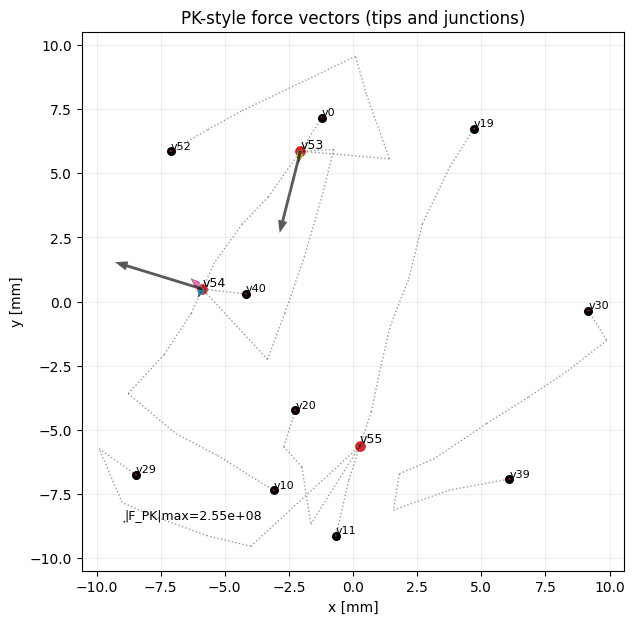

Saved figures to: /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/IntersectingNetwork


In [5]:

from pathlib import Path
import os, sys

# --- Ensure repo root on sys.path
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

# --- Preamble re-exports
from preamble import *   
enable_autoreload()

# ----------------------------
# Helper: safe plotting calls
# ----------------------------
def _call(obj, name, *args, **kwargs):
    fn = getattr(obj, name, None)
    if fn is None:
        print(f"[skip] {obj.__class__.__name__}.{name} not found")
        return None
    try:
        return fn(*args, **kwargs)
    except TypeError as e:
        # In case signature differs slightly across versions
        print(f"[warn] {obj.__class__.__name__}.{name} signature mismatch: {e}")
        return fn(*args)

# ----------------------------
# Problem definition
# ----------------------------
mm = 1e-3
generator = CrackNetworkGenerator(
    domain_size=(20*mm, 20*mm),
    seed=42
)

generator.generate_network(
    n_junctions=0,              # No junctions
    n_tips=0,                   # No isolated tips
    edge_length_mean=2*mm,
    edge_length_std=0.5*mm,
    min_edge_length=1*mm,
    max_edge_length=3*mm,
    
    # Connected crack paths
    n_crack_paths=5,                    # 5 long cracks
    segments_per_path_mean=10,          # Average 10 segments each
    segments_per_path_std=3,            # ±3 segments variation
    path_angle_change_mean_deg=0.0,     # Straight (no systematic curvature)
    path_angle_change_std_deg=10.0,     # Small random wiggles (±10°)
    
    allow_intersections=True,
    detect_intersections=True,
    min_edge_distance=1.0*mm
)

fig, ax = generator.visualize(node_size=60, edge_width=2.0)
plt.show()

# Print statistics
generator.print_statistics()

fig2, ax2 = generator.visualize(
    figsize=(12, 12),
    node_size=20,
    edge_width=2.0,
    show_labels=True,
    show_edge_labels=True,
    edge_color='black'
)
plt.show()
vertices, connectivity, vertex_types = generator.to_arrays()

net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=5,
    validate=True,
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=50e6, sigma_yy=100e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)

sol  = calc.solve(
    ne_half=40,
    representation="cheb_quad",
    node_distribution="tip_dense",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=12,
    nq_stress=16,
    crack_mode="half",
    junction_model="core",
)

res = DCEResultsNetworkV4(calc, sol)

# ----------------------------
# Output directory
# ----------------------------
out_dir = Path(r"/Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/IntersectingNetwork")
out_dir.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Plot: network graph + stress + displacements
# ----------------------------
plotter = DCEPlotterV4(res, out_dir=out_dir)

_call(plotter, "plot_network_graph")

opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=301,
    add_remote=True,
    mask_cracks=False,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2,
)
_call(plotter, "plot_stress_components_global", opts=opts, components=("sxx","syy","sxy"))

# If your core plotter has displacement methods, this will use them automatically.
# Otherwise, it will just skip.
_call(plotter, "plot_displacement_vector_field", disp_scale=5e4, mask_cracks=False)

# ----------------------------
# Plot: deformed network (trim junction faces; smooth COD/CSD if desired)
# ----------------------------
pl_def = DCEPlotterDeformedV4(res, out_dir=out_dir)
_call(
    pl_def,
    "plot_deformed_network",
    scale=6e-1,
    trim_core_junction_faces=True,
    # trim_junction_apply_mode="True",
    cod_smooth_window="5",   # change to 7/11/15 if you want manual control
    csd_smooth_window="5",
)

# ----------------------------
# Vectors: B-content and PK forces
# ----------------------------
pkplt = DCEPlotterPK(res, out_dir=out_dir)

_call(
    pkplt,
    "plot_b_content_vectors",
    style=VecPlotStyle(max_len_factor=0.18),
    user_scale=1e-3,
    units="mm",
    show_tips=True,
    show_junctions=True,
    show_sum_at_junction=True,
    annotate=True,
)

_call(
    pkplt,
    "plot_pk_force_vectors",
    style=VecPlotStyle(max_len_factor=0.18),
    user_scale=1e-3,
    units="mm",
    exclude_self=True,
    show_tips=True,
    show_junctions=True,
    n_samples_tip=32,
    annotate=True,
)

plt.show()
print("Saved figures to:", out_dir)

# ----------------------------
# Diagnostics (console)
# ----------------------------
#diagnostics.junction_constraint_diagnostics(calc=calc, sol=sol, min_degree=1)
#diagnostics.jump_vector_diagnostics(calc=calc, sol=sol, min_degree=1, only_vertices=None)



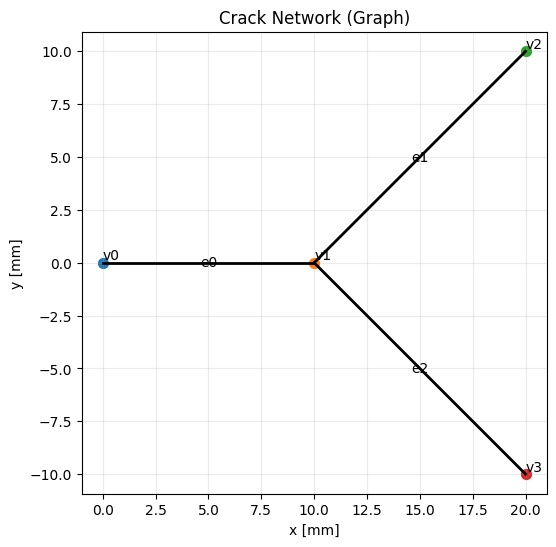

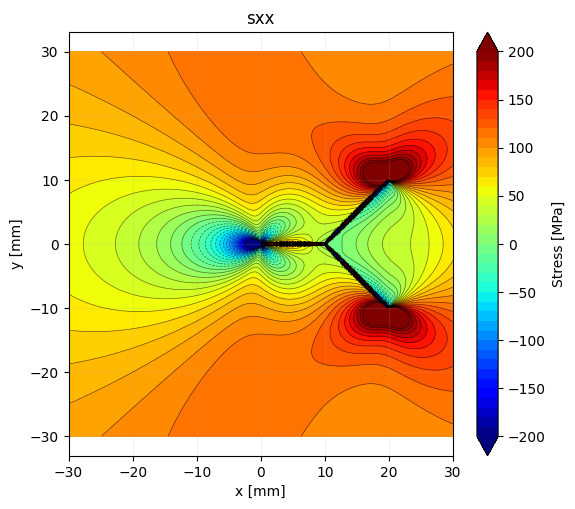

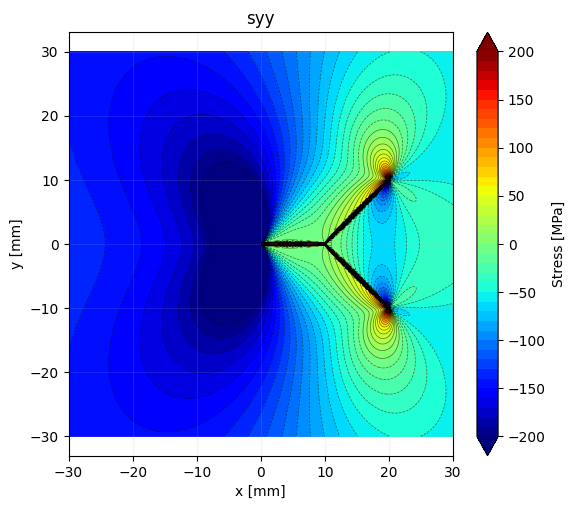

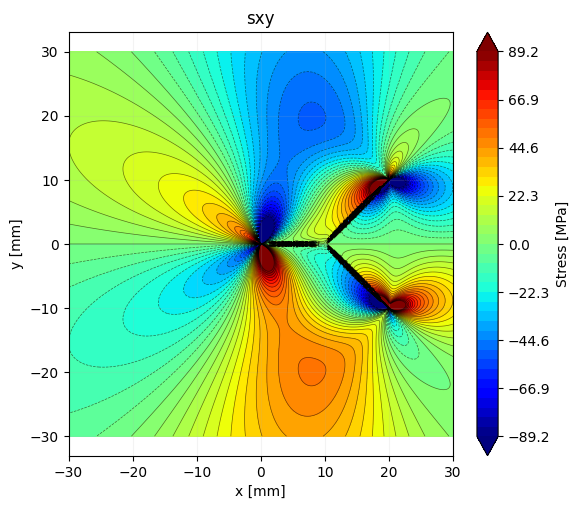

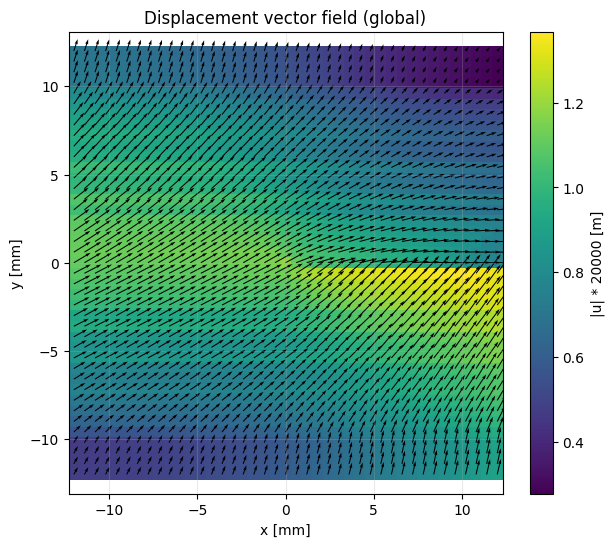

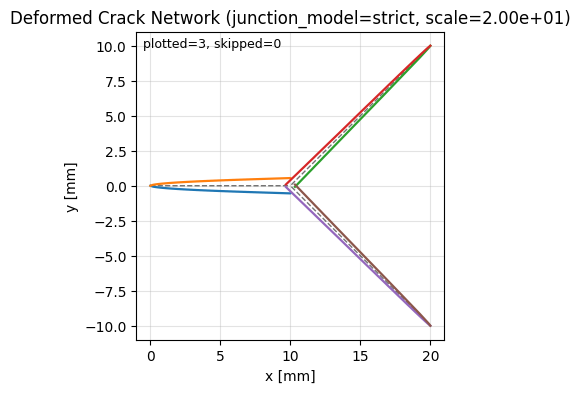

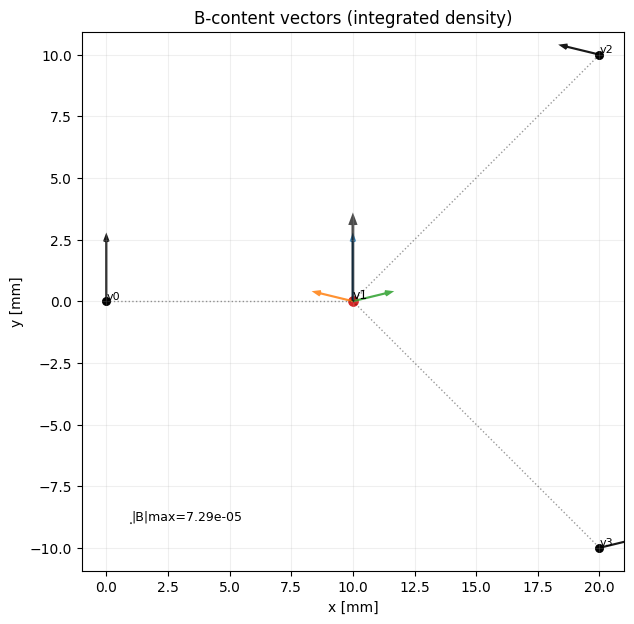

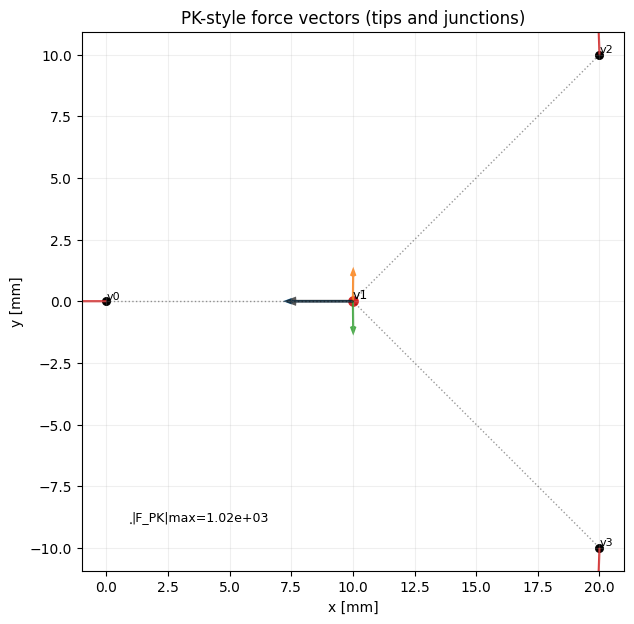

Saved figures to: /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/Y_Junction


In [1]:
from pathlib import Path
import os, sys

# --- Ensure repo root on sys.path
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

# --- Preamble re-exports
from preamble import *   
enable_autoreload()

# ----------------------------
# Helper: safe plotting calls
# ----------------------------
def _call(obj, name, *args, **kwargs):
    fn = getattr(obj, name, None)
    if fn is None:
        print(f"[skip] {obj.__class__.__name__}.{name} not found")
        return None
    try:
        return fn(*args, **kwargs)
    except TypeError as e:
        # In case signature differs slightly across versions
        print(f"[warn] {obj.__class__.__name__}.{name} signature mismatch: {e}")
        return fn(*args)

# ----------------------------
# Problem definition
# ----------------------------
mm = 1e-3
vertices = np.array([
    [0,   0.0*mm,  0.0*mm],   # v0 (left end)
    [1,  10.0*mm,  0.0*mm],   # v1 (kink / interior vertex, degree 2)
    [2,  20.0*mm,  10*mm],   # v2 (right end)
    [3,  20.0*mm,  -10*mm],   # v3 (extra vertex, not used)
], dtype=float)

connectivity = np.array([
    [0, 1],   # e0
    [1, 2],   # e1
    [1, 3]
], dtype=int)


net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=4,
    validate=True
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=100e6, sigma_yy=-100e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)

sol  = calc.solve(
    ne_half=60,
    representation="cheb_quad",
    node_distribution="tip_dense",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=12,
    nq_stress=16,
    crack_mode="half",
    junction_model="core",
)

res = DCEResultsNetworkV4(calc, sol)

# ----------------------------
# Output directory
# ----------------------------
out_dir = Path(r"/Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/Y_Junction")
out_dir.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Plot: network graph + stress + displacements
# ----------------------------
plotter = DCEPlotterV4(res, out_dir=out_dir)

_call(plotter, "plot_network_graph")

opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=301,
    add_remote=True,
    mask_cracks=False,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2,
)
_call(plotter, "plot_stress_components_global", opts=opts, components=("sxx","syy","sxy"))
_call(plotter, "plot_displacement_vector_field", disp_scale=2e4, mask_cracks=False)

# ----------------------------
# Plot: deformed network (trim junction faces; smooth COD/CSD if desired)
# ----------------------------
pl_def = DCEPlotterDeformedV4(res, out_dir=out_dir)
_call(
    pl_def,
    "plot_deformed_network",
    scale=2e1,
    junction_model="strict",
)

# ----------------------------
# Vectors: B-content and PK forces
# ----------------------------
pkplt = DCEPlotterPK(res, out_dir=out_dir)

_call(
    pkplt,
    "plot_b_content_vectors",
    style=VecPlotStyle(max_len_factor=0.18),
    user_scale=1e-3,
    units="mm",
    show_tips=True,
    show_junctions=True,
    show_sum_at_junction=True,
    annotate=True,
)

_call(
    pkplt,
    "plot_pk_force_vectors",
    style=VecPlotStyle(max_len_factor=0.18),
    user_scale=1e-3,
    units="mm",
    exclude_self=True,
    show_tips=True,
    show_junctions=True,
    n_samples_tip=32,
    annotate=True,
)

plt.show()
print("Saved figures to:", out_dir)

# ----------------------------
# Diagnostics (console)
# ----------------------------
#diagnostics.junction_constraint_diagnostics(calc=calc, sol=sol, min_degree=1)
#diagnostics.jump_vector_diagnostics(calc=calc, sol=sol, min_degree=1, only_vertices=None)


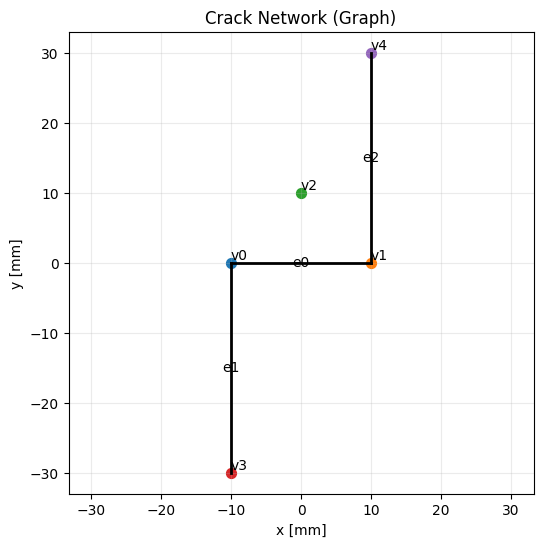

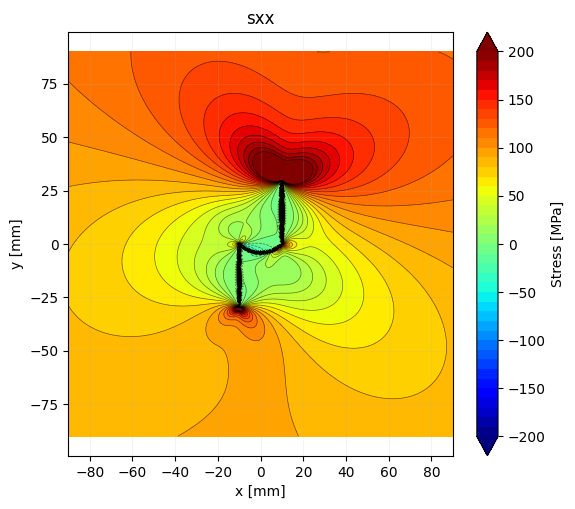

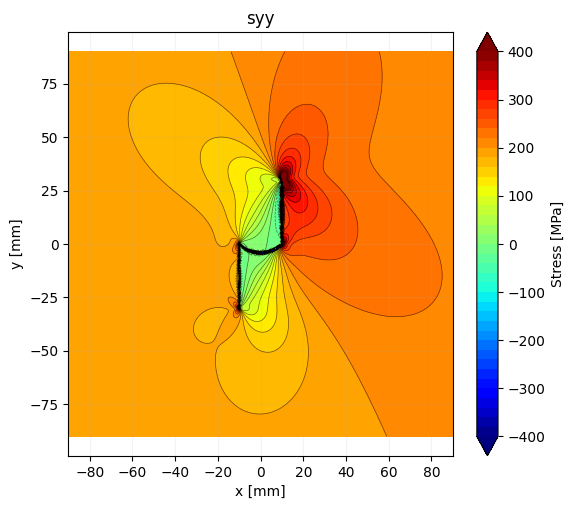

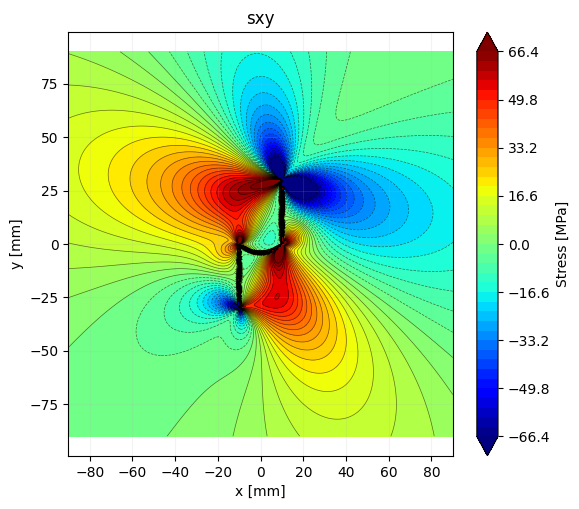

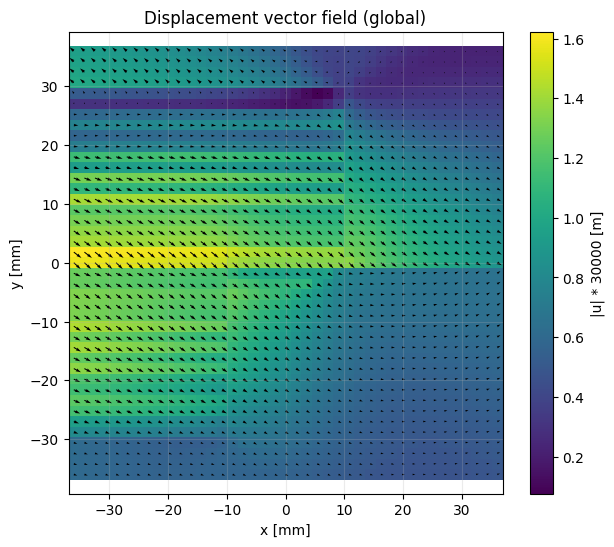

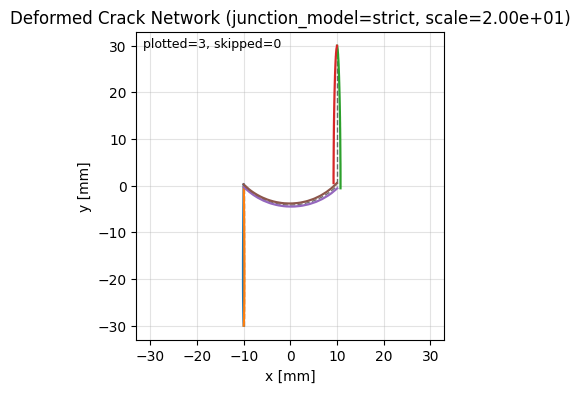

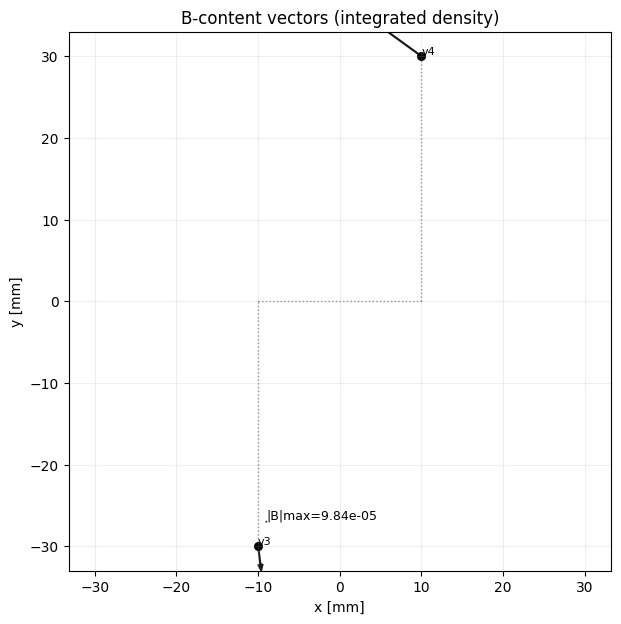

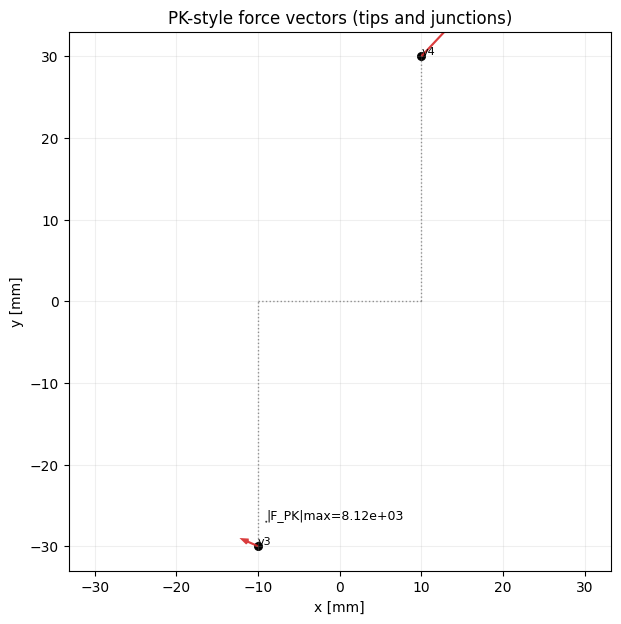

Saved figures to: /Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/CircularKink


In [7]:
from pathlib import Path
import os, sys

# --- Ensure repo root on sys.path
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

import importlib
import preamble
importlib.reload(preamble)

# --- Preamble re-exports
from preamble import *   

# ----------------------------
# Helper: safe plotting calls
# ----------------------------
def _call(obj, name, *args, **kwargs):
    fn = getattr(obj, name, None)
    if fn is None:
        print(f"[skip] {obj.__class__.__name__}.{name} not found")
        return None
    try:
        return fn(*args, **kwargs)
    except TypeError as e:
        # In case signature differs slightly across versions
        print(f"[warn] {obj.__class__.__name__}.{name} signature mismatch: {e}")
        return fn(*args)


# ----------------------------
# Problem definition
# ----------------------------
mm = 1e-3
V = np.array([
    [0, -10*mm,    0.0],     # endpoint (node)
    [1, 10*mm,  0.0],     # endpoint (node)
    [2,  0*mm,  10*mm],    # center (control)
    [3,  -10*mm, -30*mm],    
    [4, 10*mm,  30*mm],    
], float)

E = np.array([
    [0, 1], 
    [3,0],
    [1,4],   
], int)


net = CrackNetworkV4.from_vertices_connectivity(
    vertices=V,
    connectivity=E,
    Nv_max=4,
    validate=True,
    edge_kinds=["arc", "line", "line"],      # one per edge in E, same order
    edge_ctrl_vids=[(2,), (), ()],           # one per edge; only arc gets a center
    vertex_roles={2: "control"},
)


material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=100.0e6, sigma_yy=200.0e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)
sol  = calc.solve(ne_half=40, parametrization="polyline", crack_mode="half",nq_col=12, nq_stress=16, junction_model="strict")


res = DCEResultsNetworkV4(calc, sol)


# ----------------------------
# Output directory
# ----------------------------
out_dir = Path(r"/Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/CircularKink")
out_dir.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Plot: network graph + stress + displacements
# ----------------------------
plotter = DCEPlotterV4(res, out_dir=out_dir)

_call(plotter, "plot_network_graph")

opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=301,
    add_remote=True,
    mask_cracks=False,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2,
)
_call(plotter, "plot_stress_components_global", opts=opts, components=("sxx","syy","sxy"))

# If your core plotter has displacement methods, this will use them automatically.
# Otherwise, it will just skip.
_call(plotter, "plot_displacement_vector_field", disp_scale=3e4, mask_cracks=False)

# ----------------------------
# Plot: deformed network (trim junction faces; smooth COD/CSD if desired)
# ----------------------------
pl_def = DCEPlotterDeformedV4(res, out_dir=out_dir)
pl_def.plot_deformed_network(
    n_pts_per_edge=200,
    scale=2e1,
    show_faces=True,
    units="mm",
    junction_model="strict",
)

# ----------------------------
# Vectors: B-content and PK forces
# ----------------------------
pkplt = DCEPlotterPK(res, out_dir=out_dir)

_call(
    pkplt,
    "plot_b_content_vectors",
    style=VecPlotStyle(max_len_factor=0.18),
    user_scale=1e-3,
    units="mm",
    show_tips=True,
    show_junctions=True,
    show_sum_at_junction=True,
    annotate=True,
)

_call(
    pkplt,
    "plot_pk_force_vectors",
    style=VecPlotStyle(max_len_factor=0.18),
    user_scale=1e-3,
    units="mm",
    exclude_self=True,
    show_tips=True,
    show_junctions=True,
    n_samples_tip=32,
    annotate=True,
)

plt.show()
print("Saved figures to:", out_dir)

# ----------------------------
# Diagnostics (console)
# ----------------------------
#diagnostics.junction_constraint_diagnostics(calc=calc, sol=sol, min_degree=1)
#diagnostics.jump_vector_diagnostics(calc=calc, sol=sol, min_degree=1, only_vertices=None)


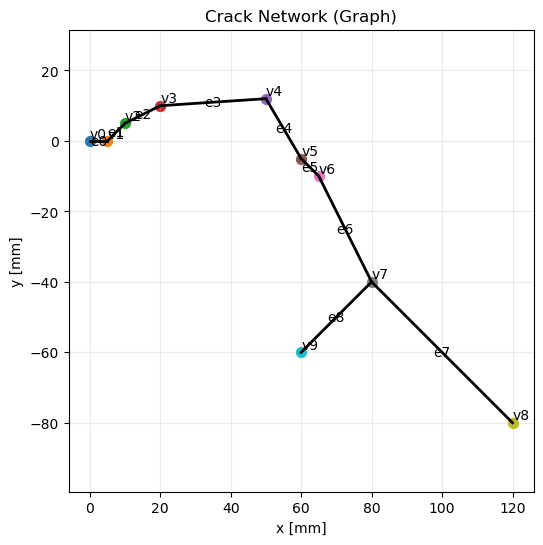

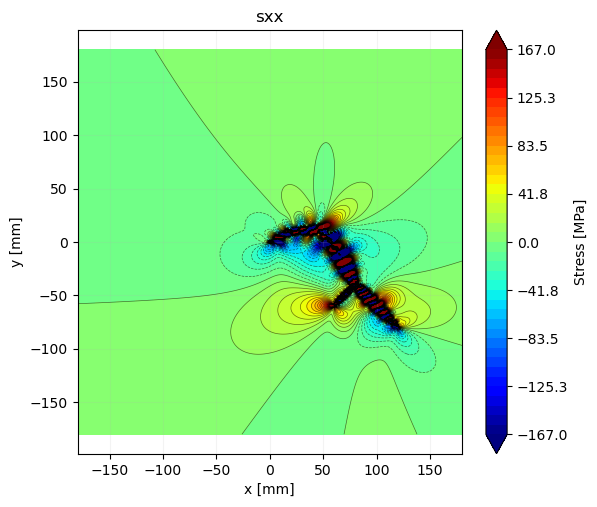

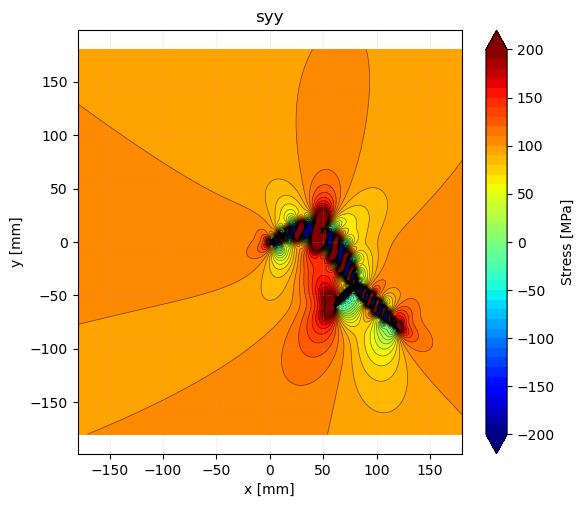

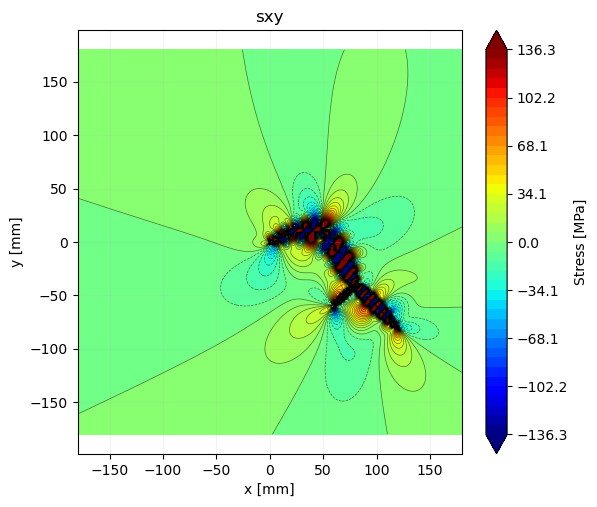

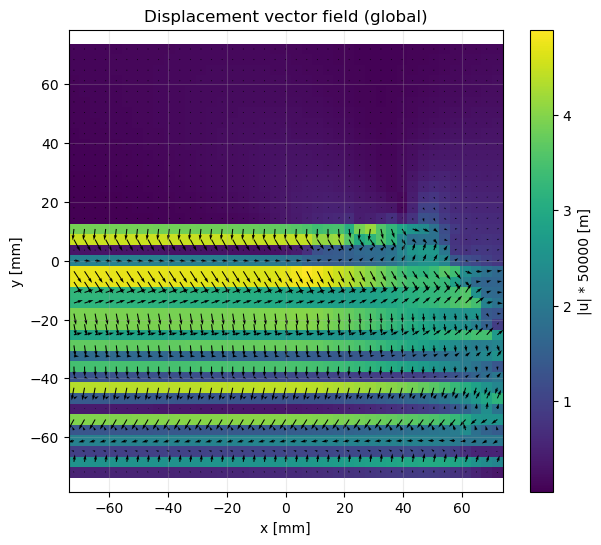

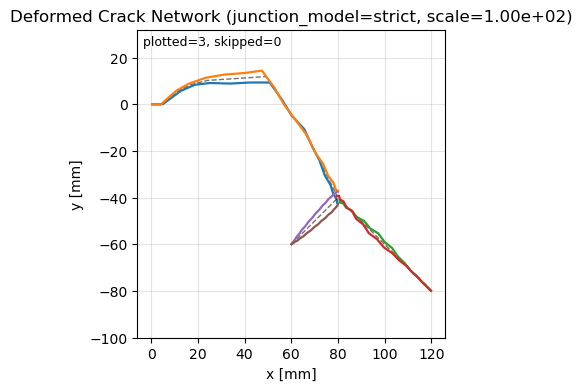

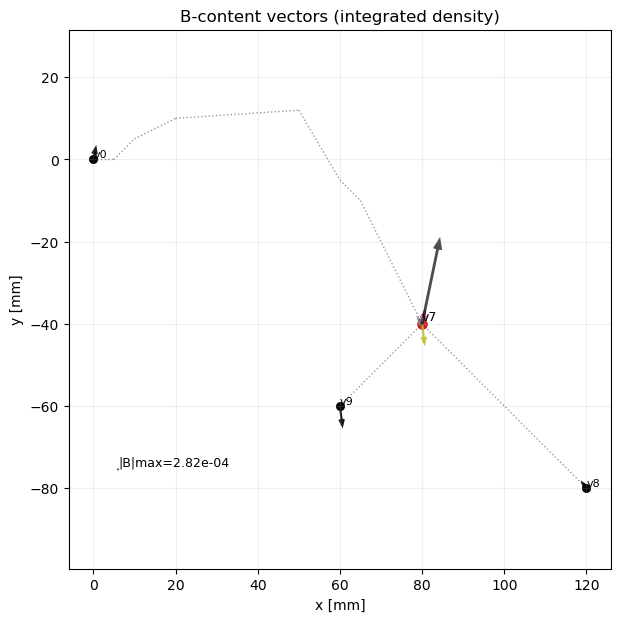

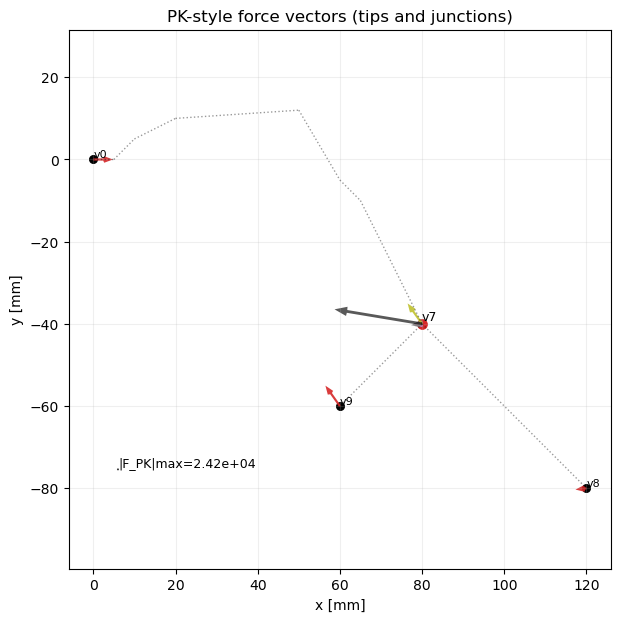

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\Yjunction_half


In [3]:
from pathlib import Path
import os, sys

# --- Ensure repo root on sys.path
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

import importlib
import preamble
importlib.reload(preamble)

# --- Preamble re-exports
from preamble import *   

# ----------------------------
# Helper: safe plotting calls
# ----------------------------
def _call(obj, name, *args, **kwargs):
    fn = getattr(obj, name, None)
    if fn is None:
        print(f"[skip] {obj.__class__.__name__}.{name} not found")
        return None
    try:
        return fn(*args, **kwargs)
    except TypeError as e:
        # In case signature differs slightly across versions
        print(f"[warn] {obj.__class__.__name__}.{name} signature mismatch: {e}")
        return fn(*args)

# ----------------------------
# Problem definition
# ----------------------------
mm = 1e-3
vertices = np.array([
    [0,   0.0*mm,  0.0*mm],   
    [1,  5.0*mm,  0.0*mm],   
    [2,  10.0*mm,  5*mm],   
    [3,  20.0*mm,  10*mm],   
    [4,  50.0*mm, 12.0*mm],
    [5,  60.0*mm, -5.0*mm],
    [6,  65.0*mm, -10*mm],
    [7,  80.0*mm, -40.0*mm],
    [8,  120.0*mm, -80.0*mm],
    [9, 60.0*mm, -60.0*mm]
], dtype=float)

connectivity = np.array([
    [0, 1],   # e0
    [1, 2],   # e1
    [2, 3],
    [3, 4],
    [4, 5],
    [5, 6],
    [6, 7],
    [7, 8],
    [7, 9],
], dtype=int)

net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=4,
    validate=True,
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=0.0, sigma_yy=100e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)

# sol = calc.solve(
#     ne_half=40,
#     crack_mode="half",
#     parametrization="polyline",
#     junction_model="strict",   # or "core"/"soft"
#     enforce_cod_nonnegative=True,
#     cod_tol=1e-10,
#     cod_max_iter=25,
# )

sol  = calc.solve(
    ne_half=10,
    representation="cheb_quad",
    node_distribution="uniform",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=3,
    nq_stress=6,
    crack_mode="half",
    enforce_cod_nonnegative=True,
    cod_tol=1e-10,
    cod_max_iter=25,
)

res = DCEResultsNetworkV4(calc, sol)

# ----------------------------
# Output directory
# ----------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\Yjunction_half")
out_dir.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Plot: network graph + stress + displacements
# ----------------------------
plotter = DCEPlotterV4(res, out_dir=out_dir)

_call(plotter, "plot_network_graph")

opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=301,
    add_remote=True,
    mask_cracks=False,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2,
)
_call(plotter, "plot_stress_components_global", opts=opts, components=("sxx","syy","sxy"))

_call(plotter, "plot_displacement_vector_field", disp_scale=5e4, mask_cracks=False)

# ----------------------------
# Plot: deformed network (trim junction faces; smooth COD/CSD if desired)
# ----------------------------
pl_def = DCEPlotterDeformedV4(res, out_dir=out_dir)
_call(
    pl_def,
    "plot_deformed_network",
    scale=1e2,
    # trim_core_junction_faces=True,
)

# ----------------------------
# Vectors: B-content and PK forces
# ----------------------------
pkplt = DCEPlotterPK(res, out_dir=out_dir)

_call(
    pkplt,
    "plot_b_content_vectors",
    style=VecPlotStyle(max_len_factor=0.18),
    user_scale=1e-3,
    units="mm",
    show_tips=True,
    show_junctions=True,
    show_sum_at_junction=True,
    annotate=True,
)

_call(
    pkplt,
    "plot_pk_force_vectors",
    style=VecPlotStyle(max_len_factor=0.18),
    user_scale=1e-3,
    units="mm",
    exclude_self=True,
    show_tips=True,
    show_junctions=True,
    n_samples_tip=32,
    annotate=True,
)

plt.show()
print("Saved figures to:", out_dir)

# ----------------------------
# Diagnostics (console)
# ----------------------------
#diagnostics.junction_constraint_diagnostics(calc=calc, sol=sol, min_degree=1)
#diagnostics.jump_vector_diagnostics(calc=calc, sol=sol, min_degree=1, only_vertices=None)
